In [3]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.aln_control import Model_ALN_control
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
a = Model_ALN_control()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

[[[5.00000000e-03 1.18660776e+01 1.22217508e+01 1.26809865e+01
   1.32465489e+01 1.38417540e+01 1.47272359e+01]]]


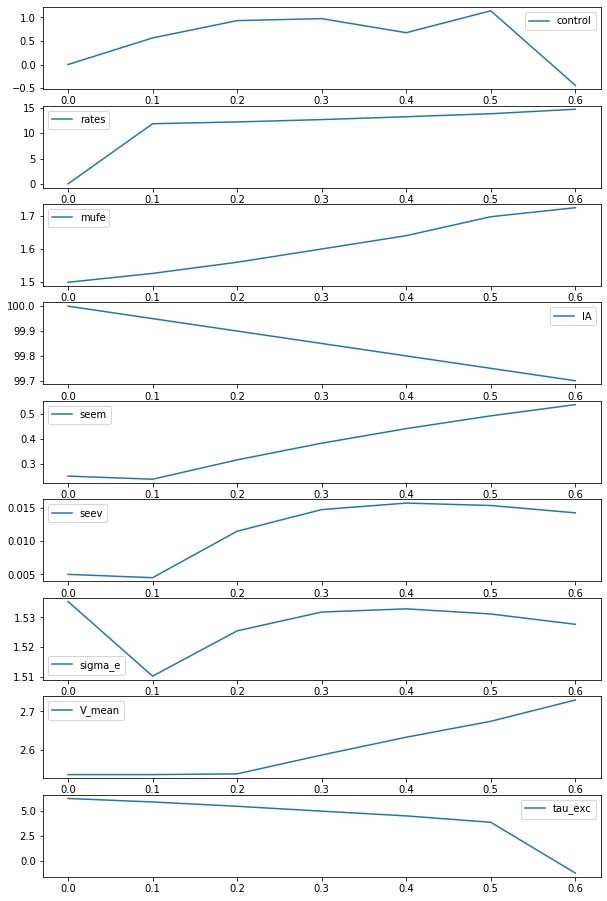

In [35]:
dur = 0.6

a.params.duration = dur
a.params.ext_exc_current = 2.

target = a.getZeroTarget()
control1 = a.getZeroControl()

control1[0,0,5] += 1.
control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.state["rates_exc"][0,:]

fig, axes = plt.subplots(9, figsize=(10, 16))
axes[0].plot(a.t, control1[0,0,:], label="control")
axes[1].plot(a.t, a.state["rates_exc"][0,:], label="rates")
axes[2].plot(a.t, a.state["mufe"][0,:], label="mufe")
axes[3].plot(a.t, a.state["IA"][0,:], label="IA")
axes[4].plot(a.t, a.state["seem"][0,:], label="seem")
axes[5].plot(a.t, a.state["seev"][0,:], label="seev")
axes[6].plot(a.t, a.state["sigmae_f"][0,:], label="sigma_e")
axes[7].plot(a.t, a.state["Vmean_exc"][0,:], label="V_mean")
axes[8].plot(a.t, a.state["tau_exc"][0,:], label="tau_exc")
for i in range(9):
    axes[i].legend()

print(target)

In [47]:
max_cntrl = 10. * 5.
start_step = 10.
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.rates_inh_init,
                             a.params.mufe_init, a.params.mufi_init, a.params.IA_init,
                             a.params.seem_init, a.params.seim_init, a.params.siem_init, a.params.siim_init,
                             a.params.seev_init, a.params.seiv_init, a.params.siev_init, a.params.siiv_init,
                             a.params.mue_ou, a.params.mui_ou] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
control2 += 1.

max_it = 200

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
RUN  0 , total integrated cost =  0.7087903916795619
RUN  1 , total integrated cost =  0.12735189833338978
RUN  2 , total integrated cost =  0.10823673534552647
RUN  3 , total integrated cost =  0.10783506575129014
RUN  4 , total integrated cost =  0.10782610195676429
RUN  5 , total integrated cost =  0.1078258971873586
RUN  6 , total integrated cost =  0.10782589246981825
RUN  7 , total integrated cost =  0.10782589236622603
RUN  8 , total integrated cost =  0.10782589236403578
RUN  9 , total integrated cost =  0.10782589236402895
RUN  10 , total integrated cost =  0.10782589236402326
RUN  11 , total integrated cost =  0.10782589236401431
RUN  12 , total integrated cost =  0.10782589236401177
RUN  13 , total integrated cost =  0.10782589236401166
RUN  14 , total integrated cost =  0.10782589236400877
RUN  15 , total integrated cost =  0.10782589236400823
RUN  16 , total integrated cost =  0.10782589236400539
RUN  17 , total integrated cost =  0.10782589236400456
RUN  1

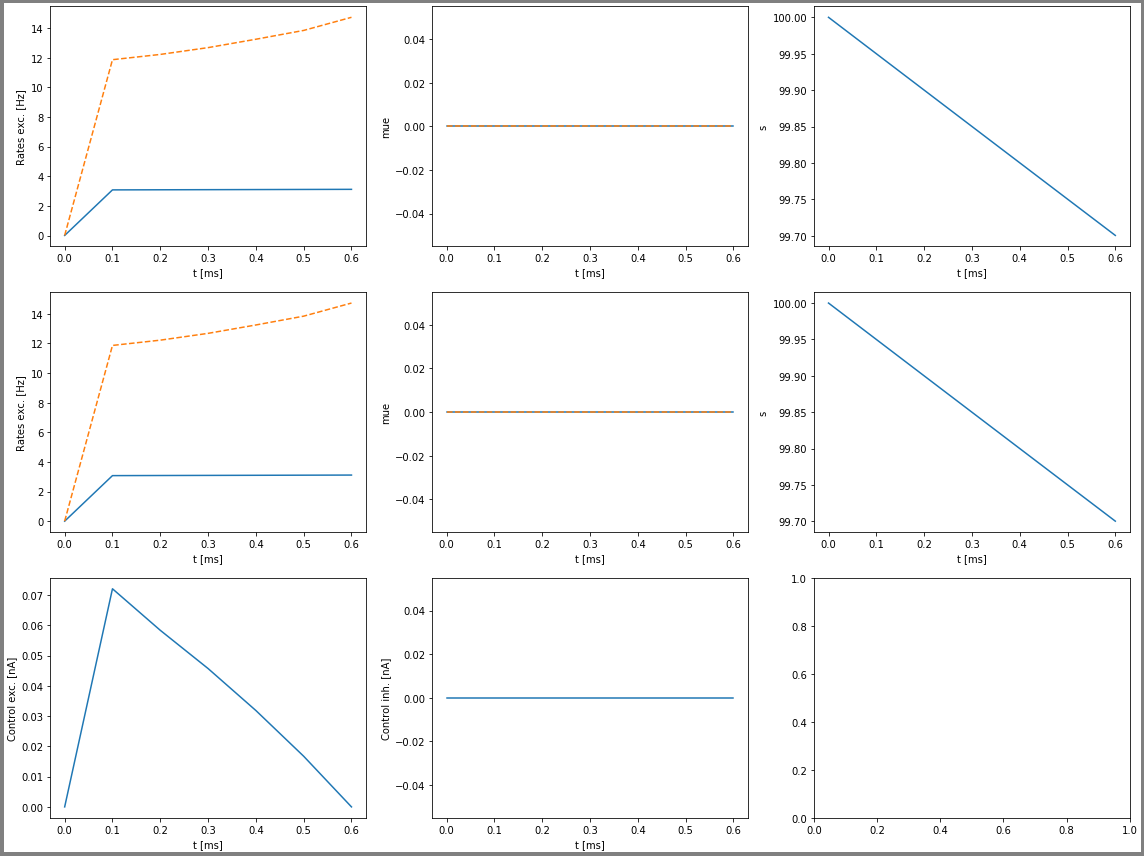

In [26]:
"""
RUN  47 , total integrated cost =  0.10782589236398443
Control only changes marginally.
Improved over  47  iterations by  84.78733718321459  percent.
final gradient =  [[[ 1.72498094e-23 -1.56126663e-08 -1.48776645e-08 -1.29658254e-08
   -9.84743870e-09 -5.39385936e-09  1.72498094e-23]]]
"""
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [86]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 30

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  1.0700223513219629
RUN  1 , total integrated cost:  0.4468907353959345
RUN  2 , total integrated cost:  0.30667752486564576
RUN  3 , total integrated cost:  0.2954172220339836
RUN  4 , total integrated cost:  0.2942715144548896
change helped, counter =  1
RUN  5 , total integrated cost:  0.29398092559342986
RUN  6 , total integrated cost:  0.29393021067134356
change helped, counter =  1
change helped, counter =  2
RUN  7 , total integrated cost:  0.29392433389350564
change helped, counter =  2
RUN  8 , total integrated cost:  0.2939240366477139
change helped, counter =  3
change helped, counter =  1
change helped, counter =  1
change helped, counter =  2
RUN  9 , total integrated cost:  0.29392390483969805
change helped, counter =  1
change helped, counter =  4
change helped, counter =  2
RUN  10 , total integrated cost:  0.29392389778555505
change helped, counter =  2
RUN  11 , total integrated cost:  0.29392389778555417
change helped, c

[[[0.         0.3391065  0.32351423 0.29888377 0.24779158 0.16599314
   0.        ]]]


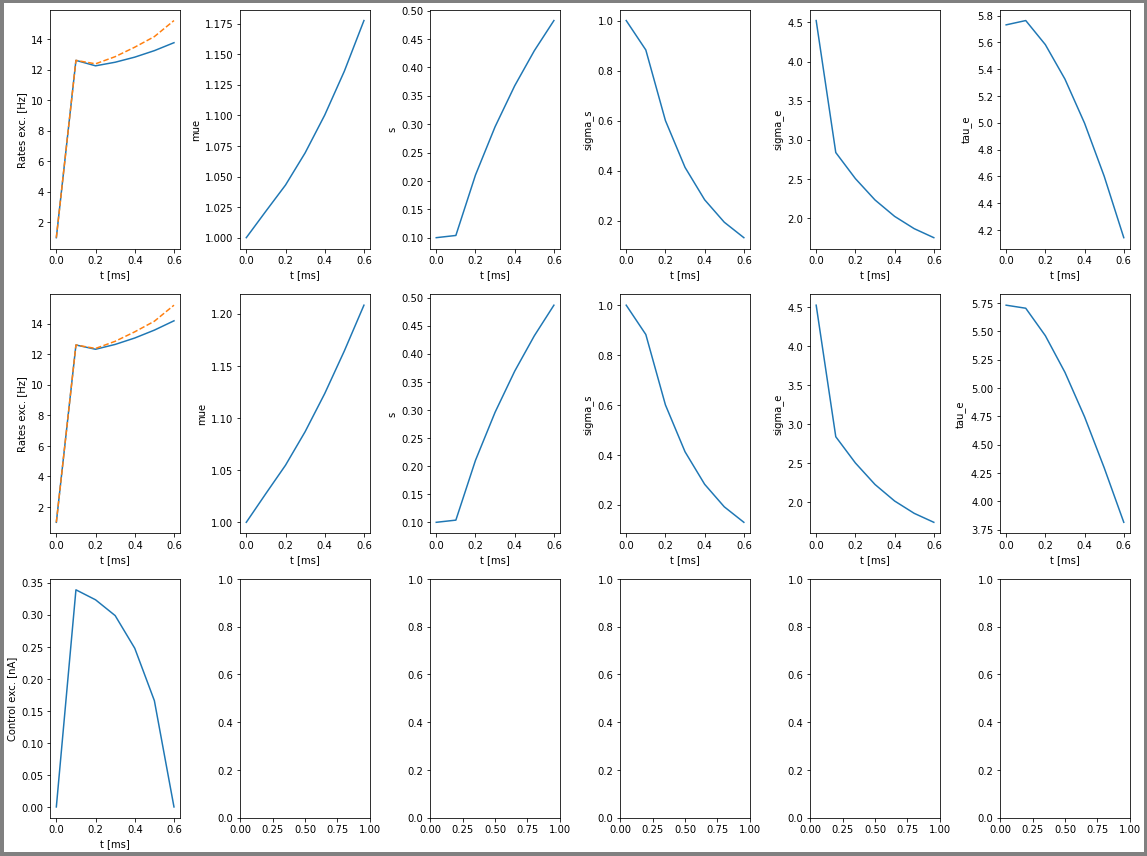

In [259]:
# 0.2939238963346936
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

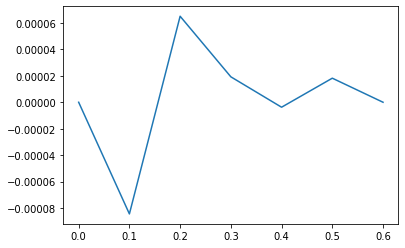

In [87]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

(350, 64, 2)


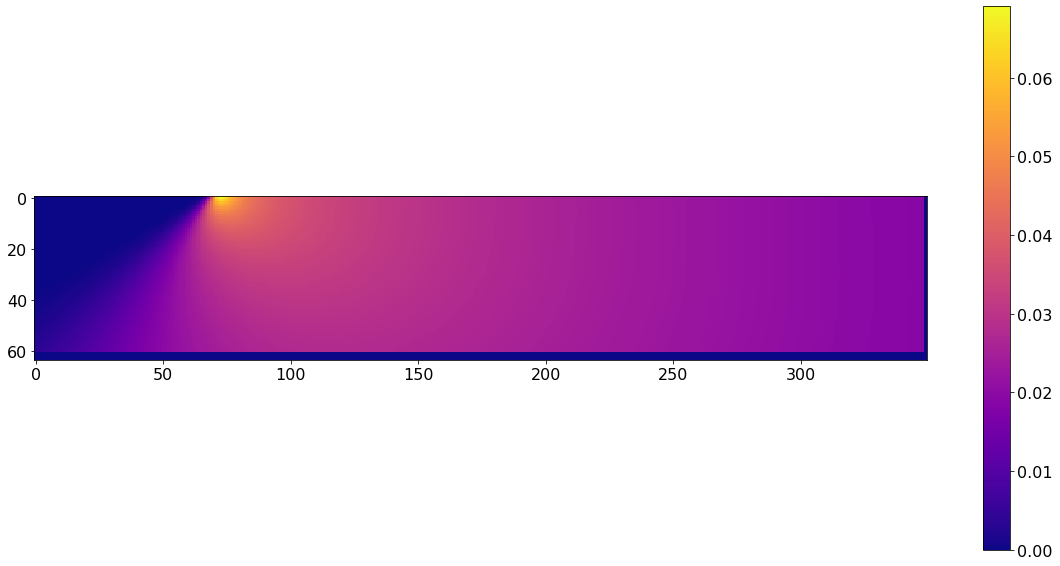

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


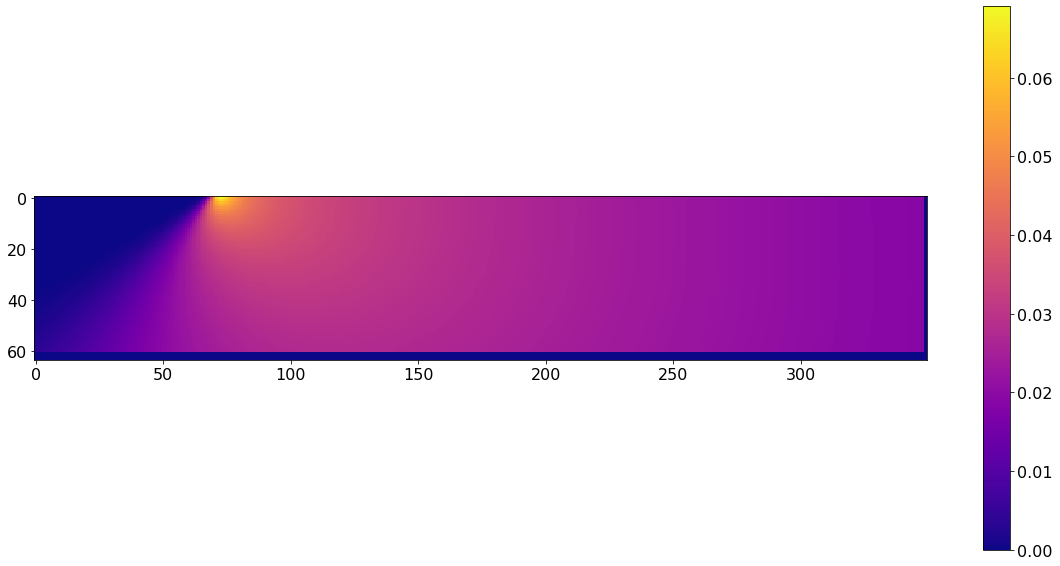

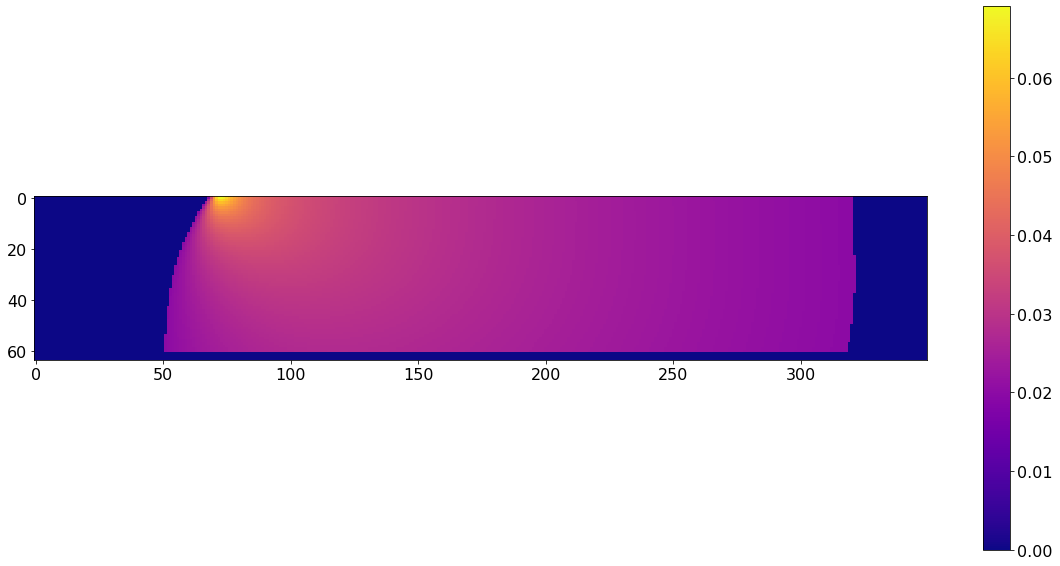

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()